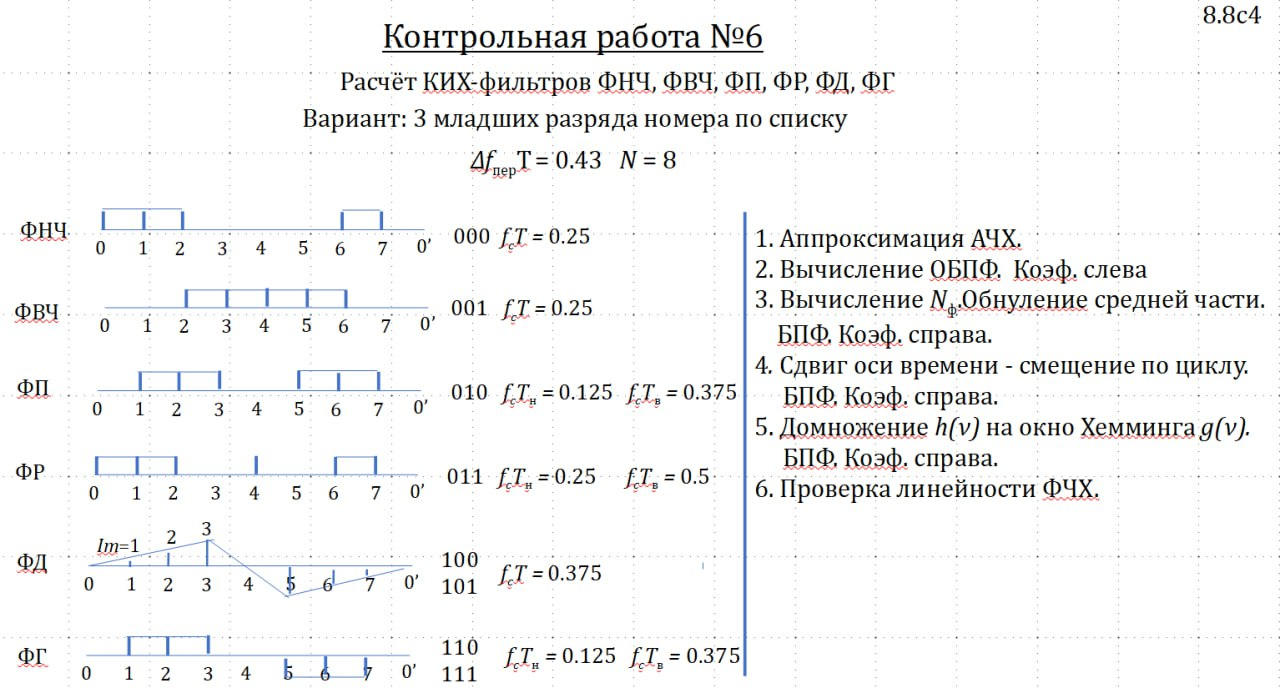

## 2.

In [416]:
import numpy as np

N = 8
dfT = 0.43

Nf = 3 / dfT

W = np.exp(-1j * np.pi / 4)
stage3 = np.array([1, 1, 1, 1, 1, 0, 0, 1])
stage2 = np.zeros(8, complex)
print('stage 3')

for n in range(8):
  # stage3[n]= final_sg[n]*final_h[n]
  print(n, ': ', np.round(stage3[n], 3))
print()

# ======================================================================

n = 0
m = 1

while m < 8:
  stage2[n] = (stage3[n] + stage3[m] * W ** 0)
  stage2[m] = (stage3[n] - stage3[m] * W ** 0)
  # print(f'n = {n}, {np.round(stage3[n], 2)} + {np.round(stage3[m], 2)} * {np.round(W ** 0, 2)}')
  # print(f'm = {m}, {np.round(stage3[n], 2)} - {np.round(stage3[m], 2)} * {np.round(W ** 0, 2)}')
  n += 2
  m += 2

print()

print('stage 2')

for n in range(8):
  print(n, ': ', np.round(stage2[n], 3))

# ======================================================================
stage1 = np.zeros(8, complex)

n = 0
m = 2
p = 0

for n in range(0, 2):
  stage1[n] = stage2[n] + stage2[m] * (W ** (-p))
  stage1[m] = stage2[n] - stage2[m] * (W ** (-p))
  # print(f'n = {n}, {np.round(stage2[n], 3)} + {np.round(stage2[m], 3)} * {np.round(W ** (-p), 3)}')
  # print(f'm = {m}, {np.round(stage2[n], 3)} - {np.round(stage2[m], 3)} * {np.round(W ** (-p), 3)}')
  m += 1
  p += 2

n = 4
m = 6
p = 0

for n in range(4, 6):
  stage1[n] = stage2[n] + stage2[m] * (W ** (-p))
  stage1[m] = stage2[n] - stage2[m] * (W ** (-p))
  # print(f'n = {n}, {np.round(stage2[n], 3)} + {np.round(stage2[m], 3)} * {np.round(W ** (-p), 3)}')
  # print(f'm = {m}, {np.round(stage2[n], 3)} - {np.round(stage2[m], 3)} * {np.round(W ** (-p), 3)}')
  m += 1
  p += 2

print()
print('stage 1')

for n in range(8):
  print(n, ': ', np.round(stage1[n], 3))

# ======================================================================

orig_sg = np.zeros(8, complex)

n = 0
m = 4

for n in range(4):
  orig_sg[n] = stage1[n] + stage1[m] * (W ** (-n))
  orig_sg[m] = stage1[n] - stage1[m] * (W ** (-n))
  # print(f'n = {n}, {np.round(stage1[n], 3)} + {np.round(stage1[m], 3)} * {np.round(W ** (-n), 3)}')
  # print(f'm = {m}, {np.round(stage1[n], 3)} - {np.round(stage1[m], 3)} * {np.round(W ** (-n), 3)}')
  m += 1

print()
print('stage 0')

for n in range(8):
  print(n, ': ', np.round(orig_sg[n], 3))

print("\nКонечный результат [*(1/N)]:")
for n in range(8):
  print(n, ': ', np.round(orig_sg[n]/8, 3))
# print("Длина вектора:")

# for n in range(8):
#   print(n, ': ', np.round(np.abs(orig_sg[n]/8), 2))

stage 3
0 :  1
1 :  1
2 :  1
3 :  1
4 :  1
5 :  0
6 :  0
7 :  1


stage 2
0 :  (2+0j)
1 :  0j
2 :  (2+0j)
3 :  0j
4 :  (1+0j)
5 :  (1+0j)
6 :  (1+0j)
7 :  (-1+0j)

stage 1
0 :  (4+0j)
1 :  0j
2 :  0j
3 :  0j
4 :  (2+0j)
5 :  (1-1j)
6 :  0j
7 :  (1+1j)

stage 0
0 :  (6+0j)
1 :  (1.414-0j)
2 :  0j
3 :  (-1.414+0j)
4 :  (2+0j)
5 :  (-1.414+0j)
6 :  0j
7 :  (1.414-0j)

Конечный результат [*(1/N)]:
0 :  (0.75+0j)
1 :  (0.177-0j)
2 :  0j
3 :  (-0.177+0j)
4 :  (0.25+0j)
5 :  (-0.177+0j)
6 :  0j
7 :  (0.177-0j)


## 3.

In [417]:
sg_list = []

print('stage 0')
for n in range(8):
  sg_list.append(orig_sg[n] / 8)

sg_list[4] = 0

for n in range(8):
  print(n, ': ', np.round(sg_list[n], 2))

# ======================================================================

W = np.exp(-1j * np.pi / 4)

stage1 = np.zeros(8, complex)

n = 0
m = 4

for n in range(4):
  stage1[n] = sg_list[n] + sg_list[m]
  stage1[m] = (sg_list[n] - sg_list[m]) * (W ** n)
  # print(f'n = {n}, {np.round(sg_list[n], 2)} + {np.round(sg_list[m], 2)}')
  # print(f'm = {m}, ({np.round(sg_list[n], 2)} - {np.round(sg_list[m], 2)}) * {np.round(W ** n, 2)}')
  m += 1
print('\nstage 1')
for n in range(8):
  print(n, ': ', np.round(stage1[n], 2))

# ======================================================================

stage2 = np.zeros(8, complex)
n = 0
m = 2
p = 0
for n in range(0, 2):
  stage2[n] = stage1[n] + stage1[m]
  stage2[m] = (stage1[n] - stage1[m]) * (W ** p)
  # print(f'n = {n}, {np.round(stage1[n], 2)} + {np.round(stage1[m], 2)}')
  # print(f'm = {m}, ({np.round(stage1[n], 2)} - {np.round(stage1[m], 2)}) * {np.round(W ** p, 2)}')
  m += 1
  p += 2

n = 4
m = 6
p = 0

for n in range(4, 6):
  stage2[n] = stage1[n] + stage1[m]
  stage2[m] = (stage1[n] - stage1[m]) * (W ** p)
  # print(f'n = {n}, {np.round(sg_list[n], 2)} + {np.round(sg_list[m], 2)}')
  # print(f'm = {m}, ({np.round(sg_list[n], 2)} - {np.round(sg_list[m], 2)}) * {np.round(W ** p, 2)}')
  m += 1
  p += 2

print('\nstage 2')

for n in range(8):
  print(n, ': ', np.round(stage2[n], 2))

# ======================================================================

stage3 = np.zeros(8, complex)

n = 0
m = 1

while m < 8:
  stage3[n] = stage2[n] + stage2[m]
  stage3[m] = (stage2[n] - stage2[m]) * (W ** 0)
  m += 2
  n += 2
print('\nstage 3')

for n in range(8):
  print(n, ': ', np.round(stage3[n], 2))


stage 0
0 :  (0.75+0j)
1 :  (0.18-0j)
2 :  0j
3 :  (-0.18+0j)
4 :  0
5 :  (-0.18+0j)
6 :  0j
7 :  (0.18-0j)

stage 1
0 :  (0.75+0j)
1 :  0j
2 :  0j
3 :  0j
4 :  (0.75+0j)
5 :  (0.25-0.25j)
6 :  0j
7 :  (0.25+0.25j)

stage 2
0 :  (0.75+0j)
1 :  0j
2 :  (0.75+0j)
3 :  0j
4 :  (0.75+0j)
5 :  (0.5+0j)
6 :  (0.75+0j)
7 :  (-0.5-0j)

stage 3
0 :  (0.75+0j)
1 :  (0.75+0j)
2 :  (0.75+0j)
3 :  (0.75+0j)
4 :  (1.25+0j)
5 :  (0.25+0j)
6 :  (0.25-0j)
7 :  (1.25+0j)


## 4.

In [418]:
dNu = int(np.round(-1 * (Nf - 1) / 2))

# shift is invereted
sg_list_rolled = np.roll(sg_list, -dNu)

for n in range(8):
  print(n, ': ', np.round(sg_list_rolled[n], 2))


# ======================================================================

W = np.exp(-1j * np.pi / 4)

stage1 = np.zeros(8, complex)

n = 0
m = 4

for n in range(4):
  stage1[n] = sg_list_rolled[n] + sg_list_rolled[m]
  stage1[m] = (sg_list_rolled[n] - sg_list_rolled[m]) * (W ** n)
  # print(f'n = {n}, {np.round(sg_list_rolled[n], 2)} + {np.round(sg_list_rolled[m], 2)}')
  # print(f'm = {m}, ({np.round(sg_list_rolled[n], 2)} - {np.round(sg_list_rolled[m], 2)}) * {np.round(W ** n, 2)}')
  m += 1
print('\nstage 1')
for n in range(8):
  print(n, ': ', np.round(stage1[n], 2))

# ======================================================================

stage2 = np.zeros(8, complex)
n = 0
m = 2
p = 0
for n in range(0, 2):
  stage2[n] = stage1[n] + stage1[m]
  stage2[m] = (stage1[n] - stage1[m]) * (W ** p)
  # print(f'n = {n}, {np.round(stage1[n], 2)} + {np.round(stage1[m], 2)}')
  # print(f'm = {m}, ({np.round(stage1[n], 2)} - {np.round(stage1[m], 2)}) * {np.round(W ** p, 2)}')
  m += 1
  p += 2

n = 4
m = 6
p = 0

for n in range(4, 6):
  stage2[n] = stage1[n] + stage1[m]
  stage2[m] = (stage1[n] - stage1[m]) * (W ** p)
  # print(f'n = {n}, {np.round(sg_list_rolled[n], 2)} + {np.round(sg_list_rolled[m], 2)}')
  # print(f'm = {m}, ({np.round(sg_list_rolled[n], 2)} - {np.round(sg_list_rolled[m], 2)}) * {np.round(W ** p, 2)}')
  m += 1
  p += 2

print('\nstage 2')

for n in range(8):
  print(n, ': ', np.round(stage2[n], 2))

# ======================================================================

stage3 = np.zeros(8, complex)

n = 0
m = 1

while m < 8:
  stage3[n] = stage2[n] + stage2[m]
  stage3[m] = (stage2[n] - stage2[m]) * (W ** 0)
  m += 2
  n += 2
print('\nstage 3')

for n in range(8):
  print(n, ': ', np.round(stage3[n], 2))

print('\nOrdered Re and Im')
print(0, ': ', np.round(stage3[0], 2))
print(1, ': ', np.round(stage3[4], 2))
print(2, ': ', np.round(stage3[2], 2))
print(3, ': ', np.round(stage3[6], 2))
print(4, ': ', np.round(stage3[1], 2))
print(5, ': ', np.round(stage3[5], 2))
print(6, ': ', np.round(stage3[3], 2))
print(7, ': ', np.round(stage3[7], 2))

print('\nAmplitude')
print(0, ': ', np.round(np.abs(stage3[0]), 2))
print(1, ': ', np.round(np.abs(stage3[4]), 2))
print(2, ': ', np.round(np.abs(stage3[2]), 2))
print(3, ': ', np.round(np.abs(stage3[6]), 2))
print(4, ': ', np.round(np.abs(stage3[1]), 2))
print(5, ': ', np.round(np.abs(stage3[5]), 2))
print(6, ': ', np.round(np.abs(stage3[3]), 2))
print(7, ': ', np.round(np.abs(stage3[7]), 2))

0 :  (-0.18+0j)
1 :  0j
2 :  (0.18-0j)
3 :  (0.75+0j)
4 :  (0.18-0j)
5 :  0j
6 :  (-0.18+0j)
7 :  0j

stage 1
0 :  0j
1 :  0j
2 :  0j
3 :  (0.75+0j)
4 :  (-0.35+0j)
5 :  0j
6 :  (-0-0.35j)
7 :  (-0.53-0.53j)

stage 2
0 :  0j
1 :  (0.75+0j)
2 :  0j
3 :  (-0+0.75j)
4 :  (-0.35-0.35j)
5 :  (-0.53-0.53j)
6 :  (-0.35+0.35j)
7 :  (0.53-0.53j)

stage 3
0 :  (0.75+0j)
1 :  (-0.75+0j)
2 :  (-0+0.75j)
3 :  -0.75j
4 :  (-0.88-0.88j)
5 :  (0.18+0.18j)
6 :  (0.18-0.18j)
7 :  (-0.88+0.88j)

Ordered Re and Im
0 :  (0.75+0j)
1 :  (-0.88-0.88j)
2 :  (-0+0.75j)
3 :  (0.18-0.18j)
4 :  (-0.75+0j)
5 :  (0.18+0.18j)
6 :  -0.75j
7 :  (-0.88+0.88j)

Amplitude
0 :  0.75
1 :  1.25
2 :  0.75
3 :  0.25
4 :  0.75
5 :  0.25
6 :  0.75
7 :  1.25


## 5.

In [419]:
hnu = sg_list_rolled
gnu = np.zeros(8, complex)
hhem = np.zeros(8, complex)

for i in range(8):
  gnu[i] = 0.54 - 0.46 * np.cos(2 * np.pi * (i / (Nf - 1)))
  print(f'\n#{i}:')
  print(f'h(Nu): {np.round(hnu[i], 3)}')
  print(f'g(Nu): {np.round(gnu[i], 3)}')
  hhem[i] = hnu[i] * gnu[i]
  print(f'h(Nu) * g(Nu): {np.round(hhem[i], 3)}')


#0:
h(Nu): (-0.177+0j)
g(Nu): (0.08+0j)
h(Nu) * g(Nu): (-0.014+0j)

#1:
h(Nu): 0j
g(Nu): (0.312+0j)
h(Nu) * g(Nu): 0j

#2:
h(Nu): (0.177-0j)
g(Nu): (0.773+0j)
h(Nu) * g(Nu): (0.137-0j)

#3:
h(Nu): (0.75+0j)
g(Nu): (1+0j)
h(Nu) * g(Nu): (0.75+0j)

#4:
h(Nu): (0.177-0j)
g(Nu): (0.763+0j)
h(Nu) * g(Nu): (0.135-0j)

#5:
h(Nu): 0j
g(Nu): (0.302+0j)
h(Nu) * g(Nu): 0j

#6:
h(Nu): (-0.177+0j)
g(Nu): (0.08+0j)
h(Nu) * g(Nu): (-0.014+0j)

#7:
h(Nu): 0j
g(Nu): (0.321+0j)
h(Nu) * g(Nu): 0j


In [420]:
for n in range(8):
  print(n, ': ', np.round(hhem[n], 3))

# ======================================================================

W = np.exp(-1j * np.pi / 4)

stage1 = np.zeros(8, complex)

n = 0
m = 4

for n in range(4):
  stage1[n] = hhem[n] + hhem[m]
  stage1[m] = (hhem[n] - hhem[m]) * (W ** n)
  # print(f'n = {n}, {np.round(hhem[n], 2)} + {np.round(hhem[m], 2)}')
  # print(f'm = {m}, ({np.round(hhem[n], 2)} - {np.round(hhem[m], 2)}) * {np.round(W ** n, 2)}')
  m += 1
print('\nstage 1')
for n in range(8):
  print(n, ': ', np.round(stage1[n], 2))

# ======================================================================

stage2 = np.zeros(8, complex)
n = 0
m = 2
p = 0
for n in range(0, 2):
  stage2[n] = stage1[n] + stage1[m]
  stage2[m] = (stage1[n] - stage1[m]) * (W ** p)
  # print(f'n = {n}, {np.round(stage1[n], 2)} + {np.round(stage1[m], 2)}')
  # print(f'm = {m}, ({np.round(stage1[n], 2)} - {np.round(stage1[m], 2)}) * {np.round(W ** p, 2)}')
  m += 1
  p += 2

n = 4
m = 6
p = 0

for n in range(4, 6):
  stage2[n] = stage1[n] + stage1[m]
  stage2[m] = (stage1[n] - stage1[m]) * (W ** p)
  # print(f'n = {n}, {np.round(hhem[n], 2)} + {np.round(hhem[m], 2)}')
  # print(f'm = {m}, ({np.round(hhem[n], 2)} - {np.round(hhem[m], 2)}) * {np.round(W ** p, 2)}')
  m += 1
  p += 2

print('\nstage 2')

for n in range(8):
  print(n, ': ', np.round(stage2[n], 2))

# ======================================================================

stage3 = np.zeros(8, complex)

n = 0
m = 1

while m < 8:
  stage3[n] = stage2[n] + stage2[m]
  stage3[m] = (stage2[n] - stage2[m]) * (W ** 0)
  m += 2
  n += 2
print('\nstage 3')

for n in range(8):
  print(n, ': ', np.round(stage3[n], 2))

0 :  (-0.014+0j)
1 :  0j
2 :  (0.137-0j)
3 :  (0.75+0j)
4 :  (0.135-0j)
5 :  0j
6 :  (-0.014+0j)
7 :  0j

stage 1
0 :  (0.12-0j)
1 :  0j
2 :  (0.12-0j)
3 :  (0.75+0j)
4 :  (-0.15+0j)
5 :  0j
6 :  (-0-0.15j)
7 :  (-0.53-0.53j)

stage 2
0 :  (0.24-0j)
1 :  (0.75+0j)
2 :  (-0+0j)
3 :  (-0+0.75j)
4 :  (-0.15-0.15j)
5 :  (-0.53-0.53j)
6 :  (-0.15+0.15j)
7 :  (0.53-0.53j)

stage 3
0 :  (0.99-0j)
1 :  (-0.51-0j)
2 :  (-0+0.75j)
3 :  (-0-0.75j)
4 :  (-0.68-0.68j)
5 :  (0.38+0.38j)
6 :  (0.38-0.38j)
7 :  (-0.68+0.68j)


In [421]:
print('\nOrdered Re and Im')
print(0, ': ', np.round(stage3[0], 2))
print(1, ': ', np.round(stage3[4], 2))
print(2, ': ', np.round(stage3[2], 2))
print(3, ': ', np.round(stage3[6], 2))
print(4, ': ', np.round(stage3[1], 2))
print(5, ': ', np.round(stage3[5], 2))
print(6, ': ', np.round(stage3[3], 2))
print(7, ': ', np.round(stage3[7], 2))

print('\nAmplitude')
print(0, ': ', np.round(np.abs(stage3[0]), 2))
print(1, ': ', np.round(np.abs(stage3[4]), 2))
print(2, ': ', np.round(np.abs(stage3[2]), 2))
print(3, ': ', np.round(np.abs(stage3[6]), 2))
print(4, ': ', np.round(np.abs(stage3[1]), 2))
print(5, ': ', np.round(np.abs(stage3[5]), 2))
print(6, ': ', np.round(np.abs(stage3[3]), 2))
print(7, ': ', np.round(np.abs(stage3[7]), 2))


Ordered Re and Im
0 :  (0.99-0j)
1 :  (-0.68-0.68j)
2 :  (-0+0.75j)
3 :  (0.38-0.38j)
4 :  (-0.51-0j)
5 :  (0.38+0.38j)
6 :  (-0-0.75j)
7 :  (-0.68+0.68j)

Amplitude
0 :  0.99
1 :  0.96
2 :  0.75
3 :  0.54
4 :  0.51
5 :  0.54
6 :  0.75
7 :  0.96


## 6.


stage 3 AMP in order
+----------+------------------------+---------------------+------------------------+----------------------+------------------------+--------------------+------------------------+---------------------+
| Field 1  |        Field 2         |       Field 3       |        Field 4         |       Field 5        |        Field 6         |      Field 7       |        Field 8         |       Field 9       |
+----------+------------------------+---------------------+------------------------+----------------------+------------------------+--------------------+------------------------+---------------------+
|    k     |           0            |          1          |           2            |          3           |           4            |         5          |           6            |          7          |
|    Re    |   0.9933211527291641   | -0.6794188936367059 | -0.0017014029207303993 | 0.38120482523440624  |  -0.5066272950729513   | 0.3812048252344059 | -0.00170140292073006

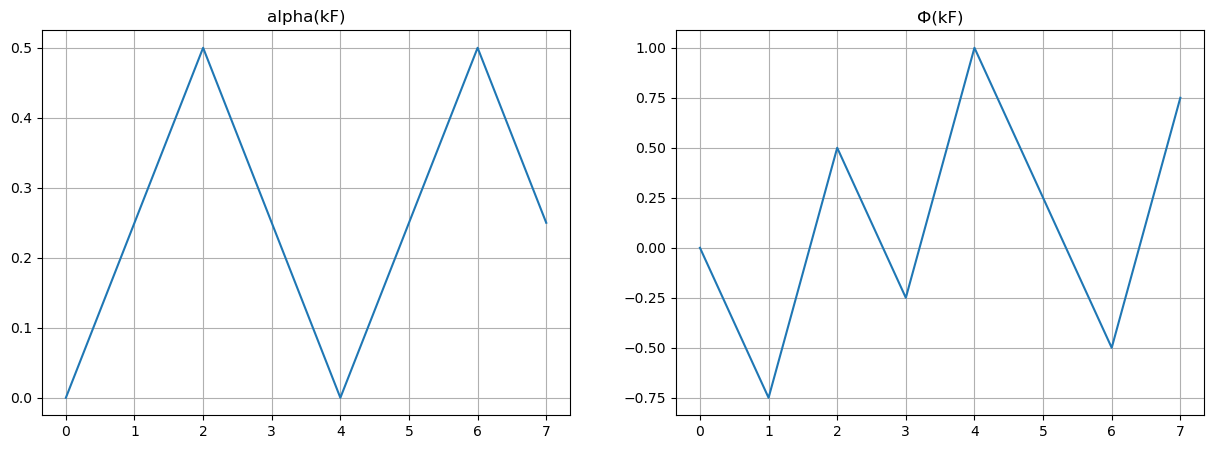

In [422]:
import matplotlib.pyplot as plt
from prettytable import PrettyTable
from math import pi
import sympy as sp

order = [0, 4, 2, 6, 1, 5, 3, 7]
stage3_ord = []
print('\nstage 3 AMP in order')
for n in range(8):
  # print(n, ': ', np.round(abs(stage3[order[n]]), 2))
  stage3_ord.append(stage3[order[n]])

alpha = []
phi = []

for n in range(8):
  stage_3_rounded = np.round(stage3_ord[n], 2)

  if (abs(np.imag(stage_3_rounded)) <= abs(np.real(stage_3_rounded)) and (abs(stage_3_rounded) != 0)):
    alpha.append(np.arctan(abs(np.imag(stage_3_rounded)) / abs(np.real(stage_3_rounded))))
  elif (abs(np.imag(stage_3_rounded)) > abs(np.real(stage_3_rounded)) and (abs(stage_3_rounded) != 0)):
    alpha.append(np.pi/2 - np.arctan(abs(np.real(stage_3_rounded)) / abs(np.imag(stage_3_rounded))))
  elif ((abs(stage_3_rounded) == 0)):
    alpha.append(0)

  if (np.real(stage_3_rounded) >= 0 and np.imag(stage_3_rounded) >= 0):
    phi.append(alpha[n])
  elif (np.real(stage_3_rounded) < 0 and np.imag(stage_3_rounded) >= 0):
    phi.append(np.pi - alpha[n])
  elif (np.real(stage_3_rounded) < 0 and np.imag(stage_3_rounded) < 0):
    phi.append(-np.pi + alpha[n])
  elif (np.real(stage_3_rounded) >= 0 and np.imag(stage_3_rounded) < 0):
    phi.append(-alpha[n])


for n in range(8):
  alpha[n] = np.round(alpha[n] / pi, 2)
  phi[n] = np.round(phi[n] / pi, 2)

last_table = PrettyTable()
last_table.add_rows(
    [
        ["k", 0, 1, 2, 3, 4, 5, 6, 7],
        ["Re", np.real(stage3_ord[0]), np.real(stage3_ord[1]), np.real(stage3_ord[2]), np.real(stage3_ord[3]), np.real(stage3_ord[4]), np.real(stage3_ord[5]), np.real(stage3_ord[6]), np.real(stage3_ord[7])],
        ["Im", np.imag(stage3_ord[0]), np.imag(stage3_ord[1]), np.imag(stage3_ord[2]), np.imag(stage3_ord[3]), np.imag(stage3_ord[4]), np.imag(stage3_ord[5]), np.imag(stage3_ord[6]), np.imag(stage3_ord[7])],
        (['Ф/pi'] + phi),
        (["alpha/pi"]+ alpha)
    ]
)
print(last_table)


plt.figure( figsize=(15, 5))
plt.subplot(121)
plt.grid()
plt.title('alpha(kF)')
plt.plot(alpha)

# plt.figure( figsize=(5, 5))
plt.subplot(122)
plt.grid()
plt.title('Ф(kF)')
plt.plot(phi)